In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [6]:
X = train['x_train'].astype(np.float32) / 255.0
y = train['y_train']

X_test = test['test_images'].astype(np.float32) / 255.0

class_names = train['class_names']

X = X.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

X = torch.tensor(X)
y = torch.tensor(y, dtype=torch.long)
X_test = torch.tensor(X_test)

In [7]:
print("Train shape:", X.shape)
print("Labels shape:", y.shape)
print("Test shape:", X_test.shape)
print("Classes:", class_names)

Train shape: torch.Size([60000, 784])
Labels shape: torch.Size([60000])
Test shape: torch.Size([15000, 784])
Classes: ['apple' 'baseballbat' 'basketball' 'clock' 'compass' 'cookie' 'donut'
 'ladder' 'mountain' 'pizza' 'rabbit' 'soccerball' 'spider' 't-shirt'
 'wheel']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)

torch.Size([48000, 784]) torch.Size([12000, 784])


In [11]:
batch_size = 256

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

In [14]:
class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 1024)
        self.bn1 = nn.BatchNorm1d(1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.bn2 = nn.BatchNorm1d(1024)
        self.fc3 = nn.Linear(1024, 15)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.gelu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.gelu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = PancakeMLP()
print("Parameters:", count_parameters(model))

Parameters: 1872911


In [16]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, epochs=30):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()

    train_accs = []
    val_accs = []

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            preds = outputs.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total
        train_accs.append(train_acc)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = outputs.argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total
        val_accs.append(val_acc)

        scheduler.step()

        print(f"Epoch {epoch+1}/{epochs} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

    return train_accs, val_accs

In [17]:
model = PancakeMLP()
train_accs, val_accs = train_model(model, epochs=30)

Epoch 1/30 | Train: 0.6351 | Val: 0.7081
Epoch 2/30 | Train: 0.7285 | Val: 0.7402
Epoch 3/30 | Train: 0.7683 | Val: 0.7544
Epoch 4/30 | Train: 0.7962 | Val: 0.7662
Epoch 5/30 | Train: 0.8162 | Val: 0.7728
Epoch 6/30 | Train: 0.8363 | Val: 0.7731
Epoch 7/30 | Train: 0.8491 | Val: 0.7819
Epoch 8/30 | Train: 0.8660 | Val: 0.7799
Epoch 9/30 | Train: 0.8804 | Val: 0.7827
Epoch 10/30 | Train: 0.8898 | Val: 0.7831
Epoch 11/30 | Train: 0.9018 | Val: 0.7833
Epoch 12/30 | Train: 0.9117 | Val: 0.7773
Epoch 13/30 | Train: 0.9229 | Val: 0.7833
Epoch 14/30 | Train: 0.9290 | Val: 0.7843
Epoch 15/30 | Train: 0.9350 | Val: 0.7800
Epoch 16/30 | Train: 0.9409 | Val: 0.7801
Epoch 17/30 | Train: 0.9478 | Val: 0.7841
Epoch 18/30 | Train: 0.9521 | Val: 0.7830
Epoch 19/30 | Train: 0.9565 | Val: 0.7865
Epoch 20/30 | Train: 0.9602 | Val: 0.7853
Epoch 21/30 | Train: 0.9634 | Val: 0.7869
Epoch 22/30 | Train: 0.9664 | Val: 0.7866
Epoch 23/30 | Train: 0.9683 | Val: 0.7856
Epoch 24/30 | Train: 0.9704 | Val: 0.7860
E

PartB

In [18]:
class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.layers(x)

In [19]:
tower_model = TowerMLP()
print("Tower Model Parameters:", count_parameters(tower_model))

Tower Model Parameters: 470543


In [20]:
tower_train_accs, tower_val_accs = train_model(tower_model, epochs=35)

Epoch 1/35 | Train: 0.6193 | Val: 0.7093
Epoch 2/35 | Train: 0.7475 | Val: 0.7352
Epoch 3/35 | Train: 0.7989 | Val: 0.7484
Epoch 4/35 | Train: 0.8355 | Val: 0.7500
Epoch 5/35 | Train: 0.8705 | Val: 0.7454
Epoch 6/35 | Train: 0.8975 | Val: 0.7457
Epoch 7/35 | Train: 0.9232 | Val: 0.7508
Epoch 8/35 | Train: 0.9433 | Val: 0.7393
Epoch 9/35 | Train: 0.9604 | Val: 0.7389
Epoch 10/35 | Train: 0.9739 | Val: 0.7439
Epoch 11/35 | Train: 0.9802 | Val: 0.7368
Epoch 12/35 | Train: 0.9857 | Val: 0.7389
Epoch 13/35 | Train: 0.9900 | Val: 0.7379
Epoch 14/35 | Train: 0.9917 | Val: 0.7373
Epoch 15/35 | Train: 0.9942 | Val: 0.7399
Epoch 16/35 | Train: 0.9965 | Val: 0.7465
Epoch 17/35 | Train: 0.9980 | Val: 0.7465
Epoch 18/35 | Train: 0.9991 | Val: 0.7473
Epoch 19/35 | Train: 0.9989 | Val: 0.7432
Epoch 20/35 | Train: 0.9994 | Val: 0.7449
Epoch 21/35 | Train: 0.9996 | Val: 0.7486
Epoch 22/35 | Train: 0.9998 | Val: 0.7472
Epoch 23/35 | Train: 0.9999 | Val: 0.7493
Epoch 24/35 | Train: 0.9999 | Val: 0.7491
E

PartC

In [21]:
class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 15)
        )
    
    def forward(self, x):
        return self.layers(x)

In [22]:
champion_model = ChampionMLP()
print("Champion Model Parameters:", count_parameters(champion_model))

Champion Model Parameters: 1731087


In [24]:
import torchvision.transforms as T

augment = T.Compose([
    T.RandomRotation(15),
    T.RandomHorizontalFlip(),
])

# Apply to batches if desired:
# In training loop: xb = augment(xb.view(-1, 28, 28)).view(-1, 784)

In [25]:
champ_train_accs, champ_val_accs = train_model(
    champion_model, 
    epochs=30
)

Epoch 1/30 | Train: 0.5813 | Val: 0.6989
Epoch 2/30 | Train: 0.7053 | Val: 0.7344
Epoch 3/30 | Train: 0.7417 | Val: 0.7510
Epoch 4/30 | Train: 0.7679 | Val: 0.7629
Epoch 5/30 | Train: 0.7901 | Val: 0.7700
Epoch 6/30 | Train: 0.8053 | Val: 0.7724
Epoch 7/30 | Train: 0.8199 | Val: 0.7791
Epoch 8/30 | Train: 0.8330 | Val: 0.7767
Epoch 9/30 | Train: 0.8452 | Val: 0.7826
Epoch 10/30 | Train: 0.8541 | Val: 0.7800
Epoch 11/30 | Train: 0.8662 | Val: 0.7887
Epoch 12/30 | Train: 0.8741 | Val: 0.7885
Epoch 13/30 | Train: 0.8835 | Val: 0.7849
Epoch 14/30 | Train: 0.8916 | Val: 0.7882
Epoch 15/30 | Train: 0.8997 | Val: 0.7881
Epoch 16/30 | Train: 0.9056 | Val: 0.7907
Epoch 17/30 | Train: 0.9107 | Val: 0.7893
Epoch 18/30 | Train: 0.9146 | Val: 0.7935
Epoch 19/30 | Train: 0.9209 | Val: 0.7944
Epoch 20/30 | Train: 0.9261 | Val: 0.7913
Epoch 21/30 | Train: 0.9304 | Val: 0.7933
Epoch 22/30 | Train: 0.9312 | Val: 0.7917
Epoch 23/30 | Train: 0.9362 | Val: 0.7921
Epoch 24/30 | Train: 0.9368 | Val: 0.7914
E

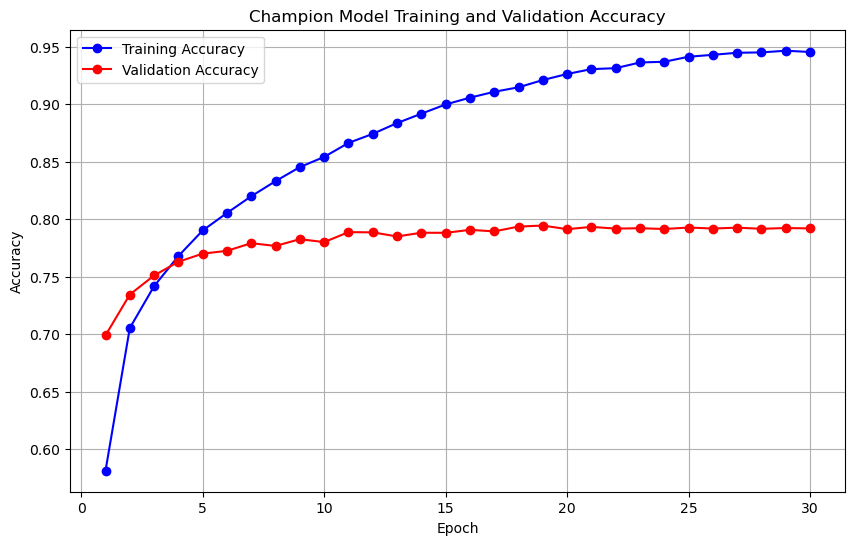

In [32]:
train_accs = champ_train_accs
val_accs = champ_val_accs

epochs = range(1, len(train_accs) + 1)

plt.figure(figsize=(10,6))
plt.plot(epochs, train_accs, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_accs, 'r-o', label='Validation Accuracy')
plt.title('Champion Model Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_loss_curves.png')  # Saves the figure for LaTeX
plt.show()

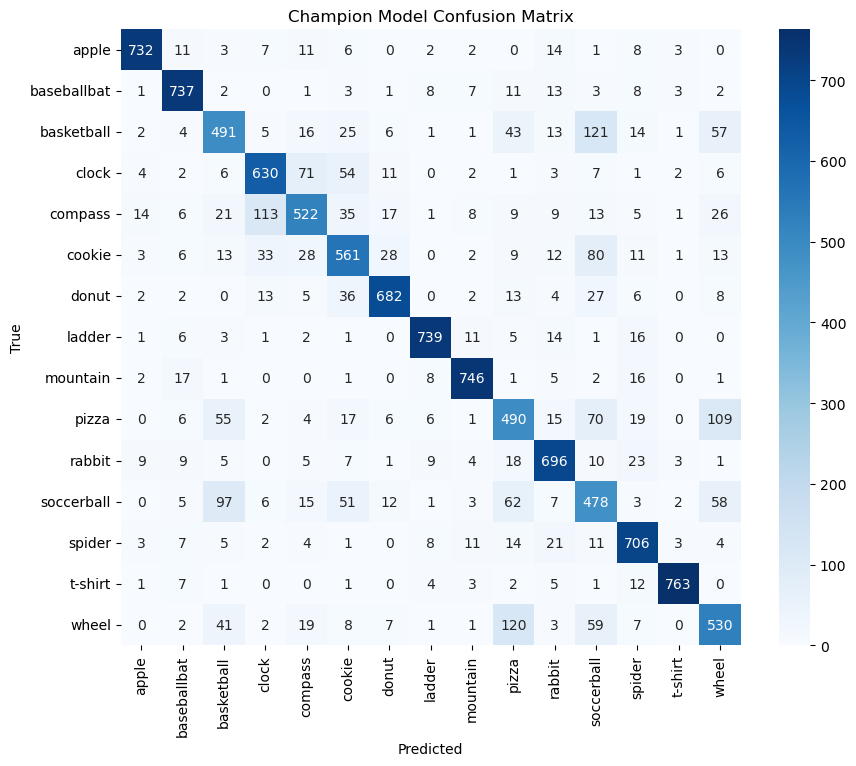

<Figure size 640x480 with 0 Axes>

In [31]:
champion_model.eval()
y_pred = []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        outputs = champion_model(xb)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)

y_true = y_val.numpy()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Champion Model Confusion Matrix")
plt.show()
plt.savefig("confusion_matrix.png")

In [28]:
# cm is your confusion matrix
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)  # ignore correct predictions

# Find indices of top 2 highest values (most confused pairs)
flat_indices = np.argsort(cm_no_diag, axis=None)[-2:][::-1]
rows, cols = np.unravel_index(flat_indices, cm_no_diag.shape)

for r, c in zip(rows, cols):
    print(f"True: {class_names[r]}, Predicted: {class_names[c]}, Count: {cm_no_diag[r, c]}")

True: basketball, Predicted: soccerball, Count: 121
True: wheel, Predicted: pizza, Count: 120


<Figure size 640x480 with 0 Axes>